# Urban Flood Frequency Analysis in India (2010–2025)

## Exploratory Data Analysis (EDA)

This notebook analyzes urban flood events in India between 2010 and 2025 using temporal, spatial, and climate-related variables. The objective is to study flood frequency trends, affected regions, seasonal patterns, and possible climate influences associated with urban flooding.

## Objective

The main objective of this analysis is to understand whether the frequency of urban flood events in India has increased over time.

The analysis also explores:
- year-wise flood trends
- most affected states and cities
- month-wise flood occurrence
- flood type distribution
- ENSO phase relationships
- antecedent rainfall characteristics

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

## Loading the Dataset

In [17]:
df = pd.read_excel("../data/India_Flood_Dataset_Final_Polished.xlsx")

In [18]:
df.head()

,DATE,YEAR,MONTH,STATE,CITY,LATITUDE,LONGITUDE,FLOOD_EVENT_NAME,FLOOD_TYPE,KERALA_MONSOON_ONSET,LOCAL_MONSOON_ONSET,DAYS_AFTER_KERALA_ONSET,ANTECEDENT_RAINFALL_MM,EL_NINO,LA_NINA,ENSO_PHASE,SOIL_MOISTURE,DATA_SOURCE
0,2010-07-25,2010,July,Maharashtra,Mumbai,19.076,72.877,Mumbai Urban Flooding 2010,Urban,2010-05-31,2010-06-12,55,325,No,Yes,Strong La Nina,High,News Archives / Wikipedia
1,2010-08-06,2010,August,Ladakh,Leh,34.152,77.577,Ladakh Flash Floods 2010,Flash,2010-05-31,2010-07-01,67,80,No,Yes,Strong La Nina,Moderate,NIDM 2025
2,2010-09-18,2010,September,Odisha,Bhubaneswar,20.296,85.824,Odisha Floods 2010,Riverine,2010-05-31,2010-06-12,110,205,No,Yes,Strong La Nina,High,NIDM 2025
3,2010-07-15,2010,July,Uttar Pradesh,Lucknow,26.846,80.946,Uttar Pradesh Floods 2010,Riverine,2010-05-31,2010-06-20,45,210,No,Yes,Strong La Nina,High,NIDM 2025
4,2010-06-15,2010,June,Assam,Guwahati,26.144,91.736,Assam Floods 2010,Riverine,2010-05-31,2010-06-05,15,340,No,Yes,Strong La Nina,Moderate,NDMA / NIDM 2025


## Dataset Overview

The dataset contains flood event records across Indian states and cities from 2010–2025 along with climate and hydrological indicators.

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   DATE                     97 non-null     object        
 1   YEAR                     97 non-null     int64         
 2   MONTH                    97 non-null     object        
 3   STATE                    97 non-null     object        
 4   CITY                     97 non-null     object        
 5   LATITUDE                 97 non-null     float64       
 6   LONGITUDE                97 non-null     float64       
 7   FLOOD_EVENT_NAME         97 non-null     object        
 8   FLOOD_TYPE               97 non-null     object        
 9   KERALA_MONSOON_ONSET     97 non-null     object        
 10  LOCAL_MONSOON_ONSET      97 non-null     datetime64[ns]
 11  DAYS_AFTER_KERALA_ONSET  97 non-null     int64         
 12  ANTECEDENT_RAINFALL_MM   97 non-null  

In [20]:
df.isnull().sum()

DATE                       0
YEAR                       0
MONTH                      0
STATE                      0
CITY                       0
LATITUDE                   0
LONGITUDE                  0
FLOOD_EVENT_NAME           0
FLOOD_TYPE                 0
KERALA_MONSOON_ONSET       0
LOCAL_MONSOON_ONSET        0
DAYS_AFTER_KERALA_ONSET    0
ANTECEDENT_RAINFALL_MM     0
EL_NINO                    0
LA_NINA                    0
ENSO_PHASE                 0
SOIL_MOISTURE              0
DATA_SOURCE                0
dtype: int64

## Year-wise Flood Frequency Analysis

In [21]:
df["YEAR"].value_counts().sort_index()

YEAR
2010     5
2011     3
2012     1
2013     5
2014     5
2015     5
2016     6
2017     6
2018     3
2019     8
2020     6
2021     8
2022    12
2023    12
2024     7
2025     5
Name: count, dtype: int64

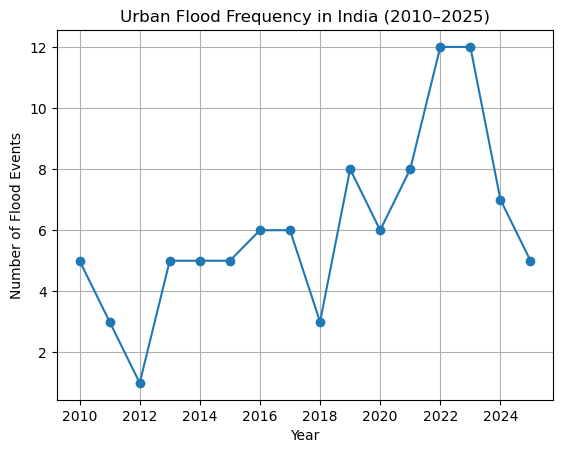

In [22]:
df["YEAR"].value_counts().sort_index().plot(kind="line", marker="o")

plt.title("Urban Flood Frequency in India (2010–2025)")
plt.xlabel("Year")
plt.ylabel("Number of Flood Events")

plt.grid(True)

plt.show()

### Observation

The graph helps visualize temporal changes in urban flood occurrence across India. An increasing trend in flood frequency may indicate rising urban flood vulnerability over time.

## State-wise Flood Distribution

In [23]:
df["STATE"].value_counts()

STATE
Assam               17
Maharashtra         11
Gujarat              8
Odisha               7
Bihar                7
Uttarakhand          5
West Bengal          5
Uttar Pradesh        5
Kerala               4
Himachal Pradesh     4
Tamil Nadu           3
Karnataka            3
Punjab               3
Jammu & Kashmir      2
Andhra Pradesh       2
Madhya Pradesh       2
Rajasthan            2
Telangana            2
Ladakh               1
Jharkhand            1
Meghalaya            1
Delhi                1
Tripura              1
Name: count, dtype: int64

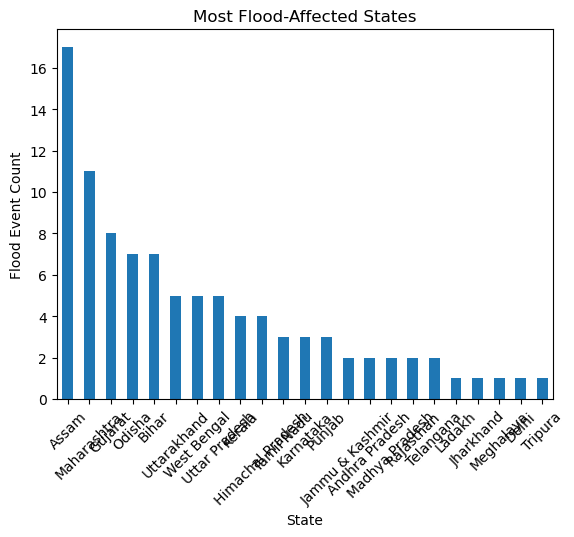

In [24]:
df["STATE"].value_counts().plot(kind="bar")

plt.title("Most Flood-Affected States")
plt.xlabel("State")
plt.ylabel("Flood Event Count")

plt.xticks(rotation=45)

plt.show()

### Observation

Certain states show significantly higher urban flood frequency, suggesting greater exposure to extreme rainfall, urbanization pressure, or hydrological vulnerability.

## City-wise Flood Distribution

In [25]:
df["CITY"].value_counts().head(10)

CITY
Guwahati       16
Mumbai          9
Bhubaneswar     7
Patna           7
Kolkata         5
Lucknow         5
Shimla          4
Vadodara        4
Kochi           3
Dehradun        3
Name: count, dtype: int64

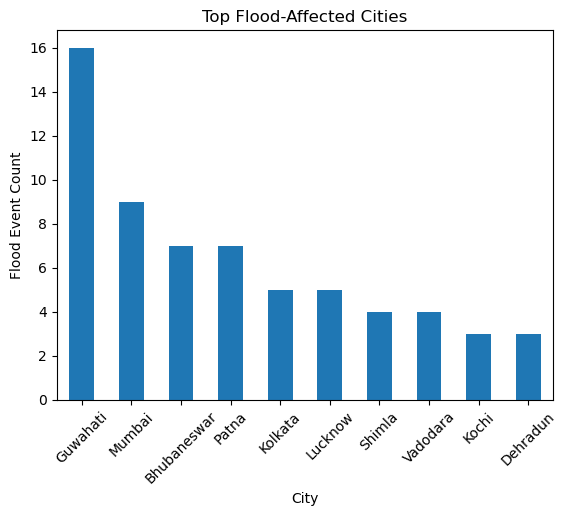

In [26]:
df["CITY"].value_counts().head(10).plot(kind="bar")

plt.title("Top Flood-Affected Cities")
plt.xlabel("City")
plt.ylabel("Flood Event Count")

plt.xticks(rotation=45)

plt.show()

## Month-wise Flood Occurrence Analysis

In [27]:
df["MONTH"].value_counts()

MONTH
July         29
August       28
June         23
September     8
October       2
December      2
May           2
November      1
February      1
April         1
Name: count, dtype: int64

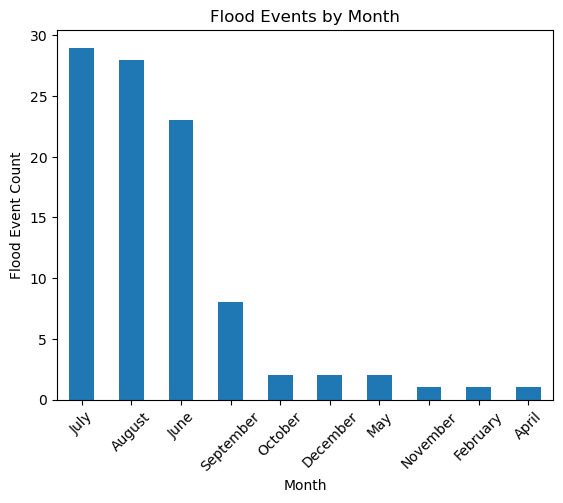

In [28]:
df["MONTH"].value_counts().plot(kind="bar")

plt.title("Flood Events by Month")
plt.xlabel("Month")
plt.ylabel("Flood Event Count")

plt.xticks(rotation=45)

plt.show()

### Observation

Most flood events are concentrated during the monsoon season, especially between June and September. This suggests a strong seasonal relationship between monsoon rainfall and urban flooding.

## Flood Type Distribution

In [29]:
df["FLOOD_TYPE"].value_counts()

FLOOD_TYPE
Riverine    61
Urban       17
Flash       16
Cyclonic     2
GLOF         1
Name: count, dtype: int64

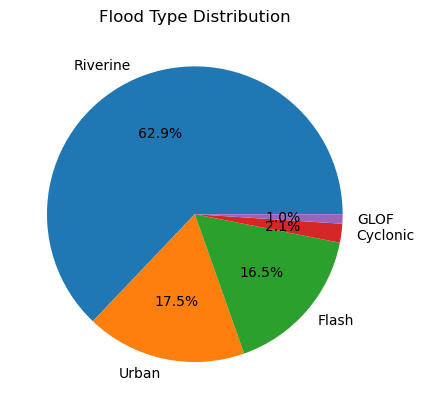

In [30]:
df["FLOOD_TYPE"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("Flood Type Distribution")

plt.ylabel("")

plt.show()

### Observation

Urban flooding forms a major proportion of the recorded flood events, indicating the increasing vulnerability of Indian cities to rainfall extremes and drainage-related challenges.

## ENSO Phase Analysis

In [31]:
df["ENSO_PHASE"].value_counts()

ENSO_PHASE
Moderate La Nina       29
Strong La Nina         17
Neutral                14
Moderate El Nino       12
Weak La Nina           12
Weak El Nino            8
Very Strong El Nino     5
Name: count, dtype: int64

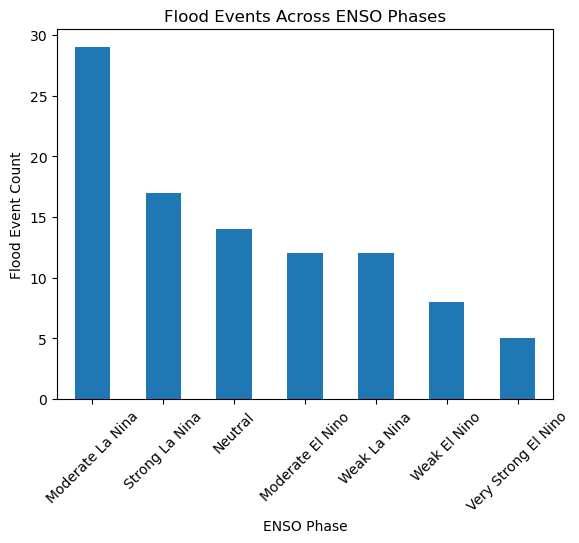

In [32]:
df["ENSO_PHASE"].value_counts().plot(kind="bar")

plt.title("Flood Events Across ENSO Phases")
plt.xlabel("ENSO Phase")
plt.ylabel("Flood Event Count")

plt.xticks(rotation=45)

plt.show()

### Observation

Flood events are distributed across different ENSO phases, suggesting possible large-scale climate influences on flood occurrence patterns in India.

## Antecedent Rainfall Analysis

In [33]:
df["ANTECEDENT_RAINFALL_MM"].describe()

count     97.000000
mean     247.701031
std      128.036548
min       65.000000
25%      165.000000
50%      220.000000
75%      300.000000
max      850.000000
Name: ANTECEDENT_RAINFALL_MM, dtype: float64

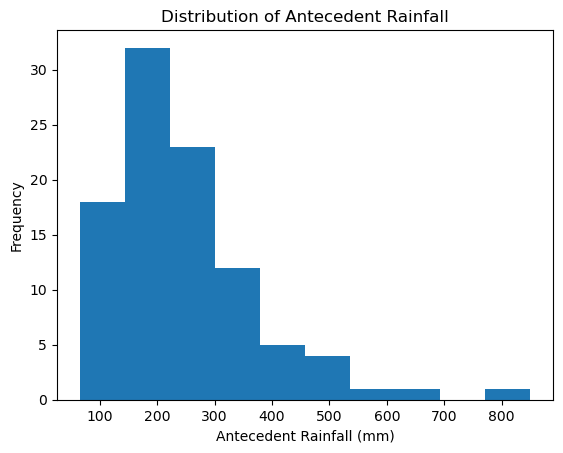

In [34]:
df["ANTECEDENT_RAINFALL_MM"].plot(kind="hist", bins=10)

plt.title("Distribution of Antecedent Rainfall")
plt.xlabel("Antecedent Rainfall (mm)")
plt.ylabel("Frequency")

plt.show()

### Observation

Higher antecedent rainfall values appear associated with several flood events, indicating the importance of prior rainfall accumulation in urban flood generation.

## Key Findings

- Urban flood events show noticeable temporal variation between 2010 and 2025.
- Certain states and cities experience significantly higher flood frequency.
- Flood occurrence is strongly concentrated during monsoon months.
- Urban flooding forms a major category of recorded flood events.
- Antecedent rainfall appears to play an important role in flood occurrence.
- ENSO phase distribution suggests possible climate-scale influences on urban flooding patterns.

## Conclusion

This exploratory analysis provides an initial understanding of urban flood patterns in India between 2010 and 2025. The study highlights increasing urban flood vulnerability, strong seasonal concentration of flood events, and the importance of climate-related factors such as antecedent rainfall and ENSO conditions.

The dataset and analysis framework developed in this project can support future work involving correlation analysis, spatial analysis, and machine learning-based flood susceptibility modeling.